# 05b — Black-Litterman v2 : relative views + cash overlay pondéré

Objectif de cette deuxième version :

1. remplacer les **absolute views** Black-Litterman par des **relative views** ;
2. appliquer le **cash overlay avec un signal pondéré par les poids réels de chaque stratégie** ;
3. comparer à nouveau :
   - Signal-adjusted PyPortfolioOpt ;
   - Signal-adjusted + cash overlay pondéré max 20 % ;
   - Black-Litterman relative views ;
   - Black-Litterman relative views + cash overlay pondéré max 20 % ;
   - PyPortfolioOpt classique ;
   - PyPortfolioOpt classique + cash overlay pondéré max 20 % ;
   - Equal-weight.

Le principe des relative views est plus cohérent avec nos signaux : on ne dit pas “TSLA fera +12 %”, on dit plutôt “le titre avec le meilleur score devrait surperformer le titre avec le pire score”.

In [1]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def find_backtesting_dir() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == "backtesting_2" and (p / "data_output").exists():
            return p
        if (p / "backtesting_2" / "data_output").exists():
            return p / "backtesting_2"
    raise FileNotFoundError(
        "Impossible de localiser le dossier backtesting_2. "
        "Lance le notebook depuis la racine du projet ou depuis backtesting_2/."
    )


BT_DIR = find_backtesting_dir()
PROJECT_ROOT = BT_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_OUTPUT = BT_DIR / "data_output"
RESULTS = BT_DIR / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

print("BT_DIR       :", BT_DIR)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("RESULTS      :", RESULTS)

BT_DIR       : /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2
PROJECT_ROOT : /Users/julio/Developer/Portfolio-Management-MODS
RESULTS      : /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results


In [2]:
try:
    from backtesting_2.config_backtest import (
        TICKERS,
        INITIAL_CAPITAL,
        FREQUENCY,
        WEIGHT_BOUNDS,
        RISK_AVERSION,
    )
except Exception:
    TICKERS = ["NKE", "TGT", "DIS", "SBUX", "TSLA"]
    INITIAL_CAPITAL = 100_000.0
    FREQUENCY = 252
    WEIGHT_BOUNDS = (0.05, 0.40)
    RISK_AVERSION = 1.0

TICKERS = list(TICKERS)

# Black-Litterman v2
BL_PRIOR = "equal"             # prior neutre, sans market caps externes
BL_TAU = 0.05                  # standard PyPortfolioOpt
BL_REL_VIEW_SCALE = 0.10       # spread score max 2 → view relative max ≈ 20 % annualisé
BL_CONFIDENCE_MIN = 0.35
BL_CONFIDENCE_MAX = 0.80
N_RELATIVE_VIEWS = 2           # top vs bottom, puis 2e top vs 2e bottom
MIN_VIEW_SPREAD = 0.05

# Cash overlay
MIN_EQUITY_EXPOSURE = 0.80     # cash max = 20 %
LOW_SIGNAL = -0.10
HIGH_SIGNAL = 0.05
CASH_DAILY_RETURN = 0.0

params = {
    "TICKERS": TICKERS,
    "INITIAL_CAPITAL": INITIAL_CAPITAL,
    "FREQUENCY": FREQUENCY,
    "WEIGHT_BOUNDS": WEIGHT_BOUNDS,
    "RISK_AVERSION": RISK_AVERSION,
    "BL_PRIOR": BL_PRIOR,
    "BL_TAU": BL_TAU,
    "BL_REL_VIEW_SCALE": BL_REL_VIEW_SCALE,
    "BL_CONFIDENCE_MIN": BL_CONFIDENCE_MIN,
    "BL_CONFIDENCE_MAX": BL_CONFIDENCE_MAX,
    "N_RELATIVE_VIEWS": N_RELATIVE_VIEWS,
    "MIN_VIEW_SPREAD": MIN_VIEW_SPREAD,
    "MIN_EQUITY_EXPOSURE": MIN_EQUITY_EXPOSURE,
    "LOW_SIGNAL": LOW_SIGNAL,
    "HIGH_SIGNAL": HIGH_SIGNAL,
}
params

{'TICKERS': ['NKE', 'TGT', 'DIS', 'SBUX', 'TSLA'],
 'INITIAL_CAPITAL': 100000.0,
 'FREQUENCY': 252,
 'WEIGHT_BOUNDS': (0.05, 0.4),
 'RISK_AVERSION': 1.0,
 'BL_PRIOR': 'equal',
 'BL_TAU': 0.05,
 'BL_REL_VIEW_SCALE': 0.1,
 'BL_CONFIDENCE_MIN': 0.35,
 'BL_CONFIDENCE_MAX': 0.8,
 'N_RELATIVE_VIEWS': 2,
 'MIN_VIEW_SPREAD': 0.05,
 'MIN_EQUITY_EXPOSURE': 0.8,
 'LOW_SIGNAL': -0.1,
 'HIGH_SIGNAL': 0.05}

## 1. Chargement des données

Le notebook utilise les sorties déjà produites par le moteur :

- `daily_global_scores.csv`
- `portfolio_returns.csv`
- `weights_history.csv`
- `prices_backtest.csv`

Il ne relance pas FinBERT. Il reconstruit seulement un backtest Black-Litterman à partir des prix et des scores.

In [3]:
GLOBAL_SCORES_CSV = DATA_OUTPUT / "daily_global_scores.csv"
PORTFOLIO_RET_CSV = RESULTS / "portfolio_returns.csv"
WEIGHTS_HISTORY_CSV = RESULTS / "weights_history.csv"
PRICES_CSV = DATA_OUTPUT / "prices_backtest.csv"

required = [GLOBAL_SCORES_CSV, PORTFOLIO_RET_CSV, WEIGHTS_HISTORY_CSV, PRICES_CSV]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Fichiers manquants :" + chr(10) + chr(10).join(missing))

prices = pd.read_csv(PRICES_CSV, parse_dates=["date"]).set_index("date").sort_index()
prices = prices.reindex(columns=TICKERS).ffill()

global_scores = pd.read_csv(GLOBAL_SCORES_CSV, parse_dates=["date"])
global_scores = global_scores[global_scores["ticker"].isin(TICKERS)].copy()

base_returns_df = pd.read_csv(PORTFOLIO_RET_CSV, parse_dates=["date", "next_date"]).sort_values("date")
base_returns = base_returns_df.set_index("date")["portfolio_return"].astype(float)
base_returns.name = "Signal-adjusted PyPortfolioOpt"

signal_weights_df = pd.read_csv(WEIGHTS_HISTORY_CSV, parse_dates=["date"])
signal_weights_df = signal_weights_df[signal_weights_df["ticker"].isin(TICKERS)].copy()

print("Prix          :", prices.index.min().date(), "→", prices.index.max().date(), prices.shape)
print("Backtest      :", base_returns.index.min().date(), "→", base_returns.index.max().date(), len(base_returns), "jours")
print("Global scores :", global_scores.shape)
print("Weights       :", signal_weights_df.shape)

base_returns_df.head()

Prix          : 2025-09-02 → 2026-06-02 (189, 5)
Backtest      : 2026-01-02 → 2026-05-28 101 jours
Global scores : (505, 5)
Weights       : (505, 3)


,date,next_date,portfolio_return,portfolio_value,cumulative_return
0,2026-01-02,2026-01-05,0.023261,102326.0550,0.023261
1,2026-01-05,2026-01-06,-0.005202,101793.7763,0.017938
2,2026-01-06,2026-01-07,-0.009299,100847.2351,0.008472
3,2026-01-07,2026-01-08,0.018224,102685.0594,0.026851
4,2026-01-08,2026-01-09,0.007746,103480.4551,0.034805


In [4]:
def build_asset_returns_by_day(prices: pd.DataFrame, schedule_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    idx = []

    for _, row in schedule_df.iterrows():
        day = row["date"]
        next_day = row["next_date"]

        if day not in prices.index or next_day not in prices.index:
            continue

        rets = (prices.loc[next_day, TICKERS] / prices.loc[day, TICKERS] - 1.0).replace([np.inf, -np.inf], np.nan)
        records.append(rets.reindex(TICKERS).fillna(0.0).to_dict())
        idx.append(day)

    return pd.DataFrame(records, index=pd.to_datetime(idx)).reindex(columns=TICKERS).sort_index()


def pivot_weights(weights_df: pd.DataFrame, dates_index: pd.Index) -> pd.DataFrame:
    w = (
        weights_df
        .pivot_table(index="date", columns="ticker", values="weight", aggfunc="sum")
        .reindex(index=dates_index, columns=TICKERS)
        .fillna(0.0)
    )
    row_sum = w.sum(axis=1).replace(0, np.nan)
    w = w.div(row_sum, axis=0).fillna(1.0 / len(TICKERS))
    return w


def equal_weight_dict(valid_tickers=None) -> dict[str, float]:
    valid_tickers = list(valid_tickers or TICKERS)
    n = len(valid_tickers)
    return {ticker: (1.0 / n if ticker in valid_tickers else 0.0) for ticker in TICKERS}


def complete_weights(weights: dict[str, float]) -> dict[str, float]:
    out = {ticker: float(weights.get(ticker, 0.0)) for ticker in TICKERS}
    s = sum(out.values())
    if abs(s) < 1e-12:
        return equal_weight_dict()
    return {ticker: value / s for ticker, value in out.items()}


asset_returns_by_day = build_asset_returns_by_day(prices, base_returns_df)
base_returns = base_returns.reindex(asset_returns_by_day.index).fillna(0.0)

signal_weights_matrix = pivot_weights(signal_weights_df, asset_returns_by_day.index)

print(asset_returns_by_day.head())
print(signal_weights_matrix.head())

                 NKE       TGT       DIS      SBUX      TSLA
2026-01-02  0.019753  0.015819  0.019848  0.030844  0.031045
2026-01-05  0.012707  0.021548  0.004383  0.033503 -0.041424
2026-01-06 -0.032594 -0.006040 -0.014489 -0.030963 -0.003580
2026-01-07  0.032268  0.025658  0.011159  0.017188  0.010176
2026-01-08  0.010113 -0.007618  0.014978  0.007938  0.021134
ticker       NKE  TGT      DIS     SBUX  TSLA
2026-01-02  0.05  0.4  0.10000  0.05000   0.4
2026-01-05  0.05  0.4  0.10000  0.05000   0.4
2026-01-06  0.05  0.4  0.05000  0.10000   0.4
2026-01-07  0.05  0.4  0.05000  0.10000   0.4
2026-01-08  0.05  0.4  0.09138  0.05862   0.4


## 2. Relative views Black-Litterman

On construit des vues relatives à partir du classement quotidien des `global_score`.

Exemple conceptuel :

```text
meilleur score : TSLA
pire score     : NKE

Vue BL :
TSLA devrait surperformer NKE
```

La taille de la vue dépend de l’écart de score :

```text
view = BL_REL_VIEW_SCALE × (score_top - score_bottom)
```

Avec `BL_REL_VIEW_SCALE = 0.10`, un écart maximal de 2 points de score donne une vue relative de 20 % annualisé.

La confiance dépend aussi de l’écart de score : plus l’écart est fort, plus la vue est fiable.

In [5]:
def build_relative_bl_views(
    scores_today: pd.DataFrame,
    valid_tickers: list[str],
    n_views: int = N_RELATIVE_VIEWS,
) -> tuple[np.ndarray | None, np.ndarray | None, list[float], pd.DataFrame]:
    # Construit des vues relatives : meilleur score vs pire score,
    # puis 2e meilleur vs 2e pire.
    scores = (
        scores_today
        .set_index("ticker")["global_score"]
        .reindex(valid_tickers)
        .fillna(0.0)
        .astype(float)
        .clip(-1.0, 1.0)
    )

    ranked = scores.sort_values(ascending=False)
    rows = []
    q = []
    confs = []
    debug = []

    max_pairs = min(n_views, len(valid_tickers) // 2)

    for k in range(max_pairs):
        long_ticker = ranked.index[k]
        short_ticker = ranked.index[-(k + 1)]

        spread = float(ranked.loc[long_ticker] - ranked.loc[short_ticker])
        if spread < MIN_VIEW_SPREAD:
            continue

        p_row = np.zeros(len(valid_tickers), dtype=float)
        p_row[valid_tickers.index(long_ticker)] = 1.0
        p_row[valid_tickers.index(short_ticker)] = -1.0

        view_return = BL_REL_VIEW_SCALE * spread
        confidence = BL_CONFIDENCE_MIN + (BL_CONFIDENCE_MAX - BL_CONFIDENCE_MIN) * min(spread / 2.0, 1.0)
        confidence = float(np.clip(confidence, 0.01, 0.99))

        rows.append(p_row)
        q.append(view_return)
        confs.append(confidence)
        debug.append({
            "long_ticker": long_ticker,
            "short_ticker": short_ticker,
            "score_long": float(ranked.loc[long_ticker]),
            "score_short": float(ranked.loc[short_ticker]),
            "score_spread": spread,
            "relative_view_annualized": view_return,
            "confidence": confidence,
        })

    if not rows:
        return None, None, [], pd.DataFrame(debug)

    P = np.vstack(rows)
    Q = np.array(q).reshape(-1, 1)

    return P, Q, confs, pd.DataFrame(debug)


first_day = asset_returns_by_day.index[0]
example_P, example_Q, example_conf, example_debug = build_relative_bl_views(
    global_scores[global_scores["date"] == first_day],
    TICKERS,
)
example_debug

,long_ticker,short_ticker,score_long,score_short,score_spread,relative_view_annualized,confidence
0,TGT,NKE,0.630831,-0.871608,1.502439,0.150244,0.688049
1,TSLA,SBUX,0.483503,-0.853272,1.336775,0.133678,0.650774


## 3. Backtest Black-Litterman avec relative views

Pour chaque jour :

1. on prend les prix historiques disponibles jusqu’au jour J ;
2. on estime la covariance via Ledoit-Wolf ;
3. on transforme les scores du jour en relative views ;
4. on calcule les rendements postérieurs Black-Litterman ;
5. on optimise avec `max_quadratic_utility` ;
6. on applique les poids au rendement J → J+1.

En cas d’échec numérique, on utilise des fallbacks : `min_volatility`, puis equal-weight.

In [6]:
def optimize_black_litterman_relative_for_day(
    train_prices: pd.DataFrame,
    scores_today: pd.DataFrame,
) -> tuple[dict[str, float], pd.Series | None, pd.DataFrame | None, pd.DataFrame]:
    from pypfopt.risk_models import CovarianceShrinkage
    from pypfopt.black_litterman import BlackLittermanModel
    from pypfopt.efficient_frontier import EfficientFrontier

    clean_prices = train_prices.reindex(columns=TICKERS).ffill().dropna(how="all")
    clean_prices = clean_prices.dropna(axis=1, how="all")

    valid_tickers = [ticker for ticker in TICKERS if ticker in clean_prices.columns]
    if len(valid_tickers) < 2 or len(clean_prices) < 30:
        return equal_weight_dict(valid_tickers), None, None, pd.DataFrame()

    clean_prices = clean_prices.reindex(columns=valid_tickers).dropna(how="any")
    if len(clean_prices) < 30:
        return equal_weight_dict(valid_tickers), None, None, pd.DataFrame()

    P, Q, confidences, debug_df = build_relative_bl_views(scores_today, valid_tickers)
    if P is None or Q is None or not confidences:
        return equal_weight_dict(valid_tickers), None, None, debug_df

    try:
        S = CovarianceShrinkage(clean_prices, frequency=FREQUENCY).ledoit_wolf()
        S = S.reindex(index=valid_tickers, columns=valid_tickers)

        bl = BlackLittermanModel(
            cov_matrix=S,
            pi=BL_PRIOR,
            P=P,
            Q=Q,
            omega="idzorek",
            view_confidences=confidences,
            tau=BL_TAU,
            risk_aversion=RISK_AVERSION,
        )

        posterior_rets = bl.bl_returns()
        posterior_cov = bl.bl_cov()

        try:
            ef = EfficientFrontier(posterior_rets, posterior_cov, weight_bounds=WEIGHT_BOUNDS)
            ef.max_quadratic_utility(risk_aversion=RISK_AVERSION)
            weights = complete_weights(dict(ef.clean_weights()))
            return weights, posterior_rets, posterior_cov, debug_df

        except Exception:
            ef = EfficientFrontier(posterior_rets, posterior_cov, weight_bounds=WEIGHT_BOUNDS)
            ef.min_volatility()
            weights = complete_weights(dict(ef.clean_weights()))
            return weights, posterior_rets, posterior_cov, debug_df

    except Exception as exc:
        print(f"Fallback equal-weight BL relative ({exc})")
        return equal_weight_dict(valid_tickers), None, None, debug_df

In [7]:
bl_returns_records = []
bl_weight_records = []
bl_posterior_records = []
bl_view_records = []

for i, row in base_returns_df.iterrows():
    day = row["date"]
    next_day = row["next_date"]

    if day not in prices.index or next_day not in prices.index:
        continue

    train_prices = prices.loc[:day, TICKERS].copy()
    scores_today = global_scores[global_scores["date"] == day]

    weights, posterior_rets, posterior_cov, debug_df = optimize_black_litterman_relative_for_day(
        train_prices=train_prices,
        scores_today=scores_today,
    )

    asset_rets = (prices.loc[next_day, TICKERS] / prices.loc[day, TICKERS] - 1.0).fillna(0.0)
    pf_ret = sum(weights.get(ticker, 0.0) * float(asset_rets[ticker]) for ticker in TICKERS)

    bl_returns_records.append({
        "date": day,
        "next_date": next_day,
        "portfolio_return": pf_ret,
    })

    for ticker in TICKERS:
        bl_weight_records.append({
            "date": day,
            "ticker": ticker,
            "weight": weights.get(ticker, 0.0),
        })

    if posterior_rets is not None:
        for ticker, value in posterior_rets.reindex(TICKERS).items():
            bl_posterior_records.append({
                "date": day,
                "ticker": ticker,
                "posterior_return": float(value) if pd.notna(value) else np.nan,
            })

    if debug_df is not None and not debug_df.empty:
        tmp = debug_df.copy()
        tmp.insert(0, "date", day)
        bl_view_records.extend(tmp.to_dict("records"))

    if (len(bl_returns_records) % 20 == 0) or (i == len(base_returns_df) - 1):
        print(f"{len(bl_returns_records)} jours BL relative calculés...")

bl_returns_df = pd.DataFrame(bl_returns_records).sort_values("date")
bl_returns = bl_returns_df.set_index("date")["portfolio_return"].astype(float)
bl_returns.name = "Black-Litterman relative views"

bl_weights_df = pd.DataFrame(bl_weight_records)
bl_weights_matrix = pivot_weights(bl_weights_df, asset_returns_by_day.index)

bl_posterior_df = pd.DataFrame(bl_posterior_records)
bl_views_df = pd.DataFrame(bl_view_records)

print("BL returns :", bl_returns.shape)
print("BL weights :", bl_weights_df.shape)
print("BL posterior :", bl_posterior_df.shape)
print("BL views :", bl_views_df.shape)

bl_returns.head()

20 jours BL relative calculés...
40 jours BL relative calculés...
60 jours BL relative calculés...
80 jours BL relative calculés...
100 jours BL relative calculés...
101 jours BL relative calculés...
BL returns : (101,)
BL weights : (505, 3)
BL posterior : (505, 3)
BL views : (201, 8)


date
2026-01-02    0.022399
2026-01-05    0.013684
2026-01-06   -0.017290
2026-01-07    0.016027
2026-01-08    0.007250
Name: Black-Litterman relative views, dtype: float64

## 4. Cash overlay pondéré par les poids propres à chaque stratégie

Correction importante vs v1 : le cash overlay ne doit pas forcément utiliser le simple score moyen des 5 actions.

On calcule maintenant :

```text
weighted_signal = somme(poids_ticker × global_score_ticker)
```

Donc le signal de cash dépend du portefeuille effectivement détenu.

In [8]:
def score_matrix_from_global_scores(global_scores: pd.DataFrame, dates_index: pd.Index) -> pd.DataFrame:
    scores = (
        global_scores
        .pivot_table(index="date", columns="ticker", values="global_score", aggfunc="mean")
        .reindex(index=dates_index, columns=TICKERS)
        .fillna(0.0)
    )
    return scores


def weighted_overlay_signal(weights_matrix: pd.DataFrame, scores_matrix: pd.DataFrame) -> pd.Series:
    w = weights_matrix.reindex(index=scores_matrix.index, columns=TICKERS).fillna(0.0)
    s = scores_matrix.reindex(index=w.index, columns=TICKERS).fillna(0.0)

    row_sum = w.sum(axis=1).replace(0, np.nan)
    w_norm = w.div(row_sum, axis=0).fillna(1.0 / len(TICKERS))

    signal = (w_norm * s).sum(axis=1)
    signal.name = "weighted_global_score"
    return signal


def exposure_from_signal(
    signal: pd.Series,
    min_equity: float = MIN_EQUITY_EXPOSURE,
    low_signal: float = LOW_SIGNAL,
    high_signal: float = HIGH_SIGNAL,
) -> pd.Series:
    exposure = pd.Series(index=signal.index, dtype=float)

    for date, x in signal.fillna(0.0).items():
        if x <= low_signal:
            e = min_equity
        elif x >= high_signal:
            e = 1.0
        else:
            z = (x - low_signal) / (high_signal - low_signal)
            e = min_equity + z * (1.0 - min_equity)
        exposure.loc[date] = float(e)

    exposure.name = "equity_exposure"
    return exposure


def apply_weighted_cash_overlay(
    risky_returns: pd.Series,
    risky_weights_matrix: pd.DataFrame,
    scores_matrix: pd.DataFrame,
    label: str,
    min_equity: float = MIN_EQUITY_EXPOSURE,
    cash_daily_return: float = CASH_DAILY_RETURN,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    signal = weighted_overlay_signal(risky_weights_matrix, scores_matrix).reindex(risky_returns.index).fillna(0.0)
    exposure = exposure_from_signal(signal, min_equity=min_equity).reindex(risky_returns.index).fillna(1.0)

    adjusted_returns = exposure * risky_returns.reindex(exposure.index).fillna(0.0) + (1.0 - exposure) * cash_daily_return
    adjusted_returns.name = label

    return adjusted_returns, exposure, signal


scores_matrix = score_matrix_from_global_scores(global_scores, asset_returns_by_day.index)

signal_weighted_score = weighted_overlay_signal(signal_weights_matrix, scores_matrix)
bl_weighted_score = weighted_overlay_signal(bl_weights_matrix, scores_matrix)

pd.DataFrame({
    "signal_adjusted_weighted_score": signal_weighted_score,
    "bl_relative_weighted_score": bl_weighted_score,
}).describe()

,signal_adjusted_weighted_score,bl_relative_weighted_score
count,101.000000,101.000000
mean,0.198996,0.307892
std,0.187763,0.169134
min,-0.238644,-0.209829
25%,0.087570,0.231146
50%,0.202941,0.322482
75%,0.344560,0.399779
max,0.603393,0.613829


## 5. Benchmarks : classique et equal-weight

Le benchmark PyPortfolioOpt classique est reconstruit avec une optimisation historique, sans signal FinBERT/momentum.

Pour comparer proprement le cash overlay, on lui applique aussi un signal pondéré par ses propres poids.

In [9]:
def compute_equal_weight_returns(asset_returns_by_day: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    weights = pd.DataFrame(
        1.0 / len(TICKERS),
        index=asset_returns_by_day.index,
        columns=TICKERS,
    )
    returns = (weights * asset_returns_by_day.reindex(columns=TICKERS).fillna(0.0)).sum(axis=1)
    returns.name = "Equal-weight"
    return returns, weights


def compute_classic_static_returns(
    prices: pd.DataFrame,
    schedule_df: pd.DataFrame,
) -> tuple[pd.Series, dict[str, float], pd.DataFrame]:
    from pypfopt.expected_returns import mean_historical_return
    from pypfopt.risk_models import CovarianceShrinkage
    from pypfopt.efficient_frontier import EfficientFrontier

    first_day = schedule_df["date"].min()
    train = prices.loc[:first_day, TICKERS].ffill().dropna(how="all").dropna(axis=1, how="all")
    valid_tickers = [ticker for ticker in TICKERS if ticker in train.columns]

    if len(train) < 30 or len(valid_tickers) < 2:
        weights = equal_weight_dict(valid_tickers)
    else:
        train = train.reindex(columns=valid_tickers).dropna(how="any")
        try:
            mu = mean_historical_return(train, frequency=FREQUENCY)
            S = CovarianceShrinkage(train, frequency=FREQUENCY).ledoit_wolf()

            try:
                ef = EfficientFrontier(mu, S, weight_bounds=WEIGHT_BOUNDS)
                ef.max_quadratic_utility(risk_aversion=RISK_AVERSION)
                weights = complete_weights(dict(ef.clean_weights()))
            except Exception:
                ef = EfficientFrontier(mu, S, weight_bounds=WEIGHT_BOUNDS)
                ef.min_volatility()
                weights = complete_weights(dict(ef.clean_weights()))

        except Exception as exc:
            print(f"Fallback equal-weight benchmark classique ({exc})")
            weights = equal_weight_dict(valid_tickers)

    returns = []
    dates = []

    for _, row in schedule_df.iterrows():
        day = row["date"]
        next_day = row["next_date"]

        if day not in prices.index or next_day not in prices.index:
            continue

        asset_rets = (prices.loc[next_day, TICKERS] / prices.loc[day, TICKERS] - 1.0).fillna(0.0)
        pf_ret = sum(weights.get(ticker, 0.0) * float(asset_rets[ticker]) for ticker in TICKERS)

        returns.append(pf_ret)
        dates.append(day)

    returns = pd.Series(returns, index=pd.to_datetime(dates), name="PyPortfolioOpt classique")
    weights_matrix = pd.DataFrame(
        [weights for _ in returns.index],
        index=returns.index,
        columns=TICKERS,
    ).fillna(0.0)

    return returns, weights, weights_matrix


eq_returns, eq_weights_matrix = compute_equal_weight_returns(asset_returns_by_day)
classic_returns, classic_weights, classic_weights_matrix = compute_classic_static_returns(prices, base_returns_df)

classic_returns = classic_returns.reindex(asset_returns_by_day.index).fillna(0.0)
classic_weights_matrix = classic_weights_matrix.reindex(asset_returns_by_day.index).ffill().fillna(1.0 / len(TICKERS))

print("Poids PyPortfolioOpt classique :", {k: round(v, 4) for k, v in classic_weights.items()})

Poids PyPortfolioOpt classique : {'NKE': 0.05, 'TGT': 0.4, 'DIS': 0.1, 'SBUX': 0.05, 'TSLA': 0.4}


In [10]:
signal_cash20, signal_exposure20, signal_cash_score = apply_weighted_cash_overlay(
    risky_returns=base_returns,
    risky_weights_matrix=signal_weights_matrix,
    scores_matrix=scores_matrix,
    label="Signal-adjusted + weighted cash overlay max 20%",
)

bl_cash20, bl_exposure20, bl_cash_score = apply_weighted_cash_overlay(
    risky_returns=bl_returns,
    risky_weights_matrix=bl_weights_matrix,
    scores_matrix=scores_matrix,
    label="BL relative + weighted cash overlay max 20%",
)

classic_cash20, classic_exposure20, classic_cash_score = apply_weighted_cash_overlay(
    risky_returns=classic_returns,
    risky_weights_matrix=classic_weights_matrix,
    scores_matrix=scores_matrix,
    label="Classic + weighted cash overlay max 20%",
)

cash_diagnostics = pd.DataFrame({
    "signal_score": signal_cash_score,
    "signal_exposure": signal_exposure20,
    "bl_score": bl_cash_score,
    "bl_exposure": bl_exposure20,
    "classic_score": classic_cash_score,
    "classic_exposure": classic_exposure20,
})

cash_diagnostics.describe()

,signal_score,signal_exposure,bl_score,bl_exposure,classic_score,classic_exposure
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.198996,0.970898,0.307892,0.990321,0.155306,0.962598
std,0.187763,0.063324,0.169134,0.039859,0.181025,0.068427
min,-0.238644,0.800000,-0.209829,0.800000,-0.235997,0.800000
25%,0.087570,1.000000,0.231146,1.000000,0.009643,0.946191
50%,0.202941,1.000000,0.322482,1.000000,0.156992,1.000000
75%,0.344560,1.000000,0.399779,1.000000,0.258650,1.000000
max,0.603393,1.000000,0.613829,1.000000,0.541884,1.000000


## 6. Comparaison des performances

In [11]:
def performance_metrics(returns: pd.Series, initial_capital: float = INITIAL_CAPITAL) -> dict:
    returns = returns.dropna().astype(float)
    if len(returns) == 0:
        return {
            "rendement_total": np.nan,
            "rendement_annualise": np.nan,
            "volatilite_annualisee": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "n_jours": 0,
        }

    cumulative = (1.0 + returns).cumprod()
    total_return = cumulative.iloc[-1] - 1.0
    annual_return = cumulative.iloc[-1] ** (FREQUENCY / len(returns)) - 1.0
    annual_vol = returns.std() * np.sqrt(FREQUENCY)

    sharpe = annual_return / annual_vol if annual_vol > 1e-12 else np.nan

    values = initial_capital * cumulative
    running_max = values.cummax()
    drawdown = values / running_max - 1.0
    max_dd = drawdown.min()

    return {
        "rendement_total": total_return,
        "rendement_annualise": annual_return,
        "volatilite_annualisee": annual_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_dd,
        "n_jours": len(returns),
    }


comparison_series = {
    "Signal-adjusted PyPortfolioOpt": base_returns,
    signal_cash20.name: signal_cash20,
    "Black-Litterman relative views": bl_returns,
    bl_cash20.name: bl_cash20,
    "PyPortfolioOpt classique": classic_returns,
    classic_cash20.name: classic_cash20,
    "Equal-weight": eq_returns,
}

summary_rows = []
for name, series in comparison_series.items():
    m = performance_metrics(series)
    m["strategie"] = name
    summary_rows.append(m)

comparison = pd.DataFrame(summary_rows)[[
    "strategie",
    "rendement_total",
    "rendement_annualise",
    "volatilite_annualisee",
    "sharpe_ratio",
    "max_drawdown",
    "n_jours",
]]

comparison = comparison.sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
comparison

,strategie,rendement_total,rendement_annualise,volatilite_annualisee,sharpe_ratio,max_drawdown,n_jours
0,Signal-adjusted + weighted cash overlay max 20%,0.137390,0.378785,0.220516,1.717720,-0.072126,101
1,Signal-adjusted PyPortfolioOpt,0.129798,0.355936,0.226767,1.569611,-0.079813,101
2,BL relative + weighted cash overlay max 20%,0.108973,0.294434,0.198668,1.482040,-0.081831,101
3,Classic + weighted cash overlay max 20%,0.109448,0.295819,0.213353,1.386524,-0.082412,101
4,Black-Litterman relative views,0.099058,0.265752,0.201552,1.318526,-0.090767,101
5,PyPortfolioOpt classique,0.102561,0.275841,0.221500,1.245336,-0.091287,101
6,Equal-weight,0.020270,0.051344,0.201904,0.254298,-0.128272,101


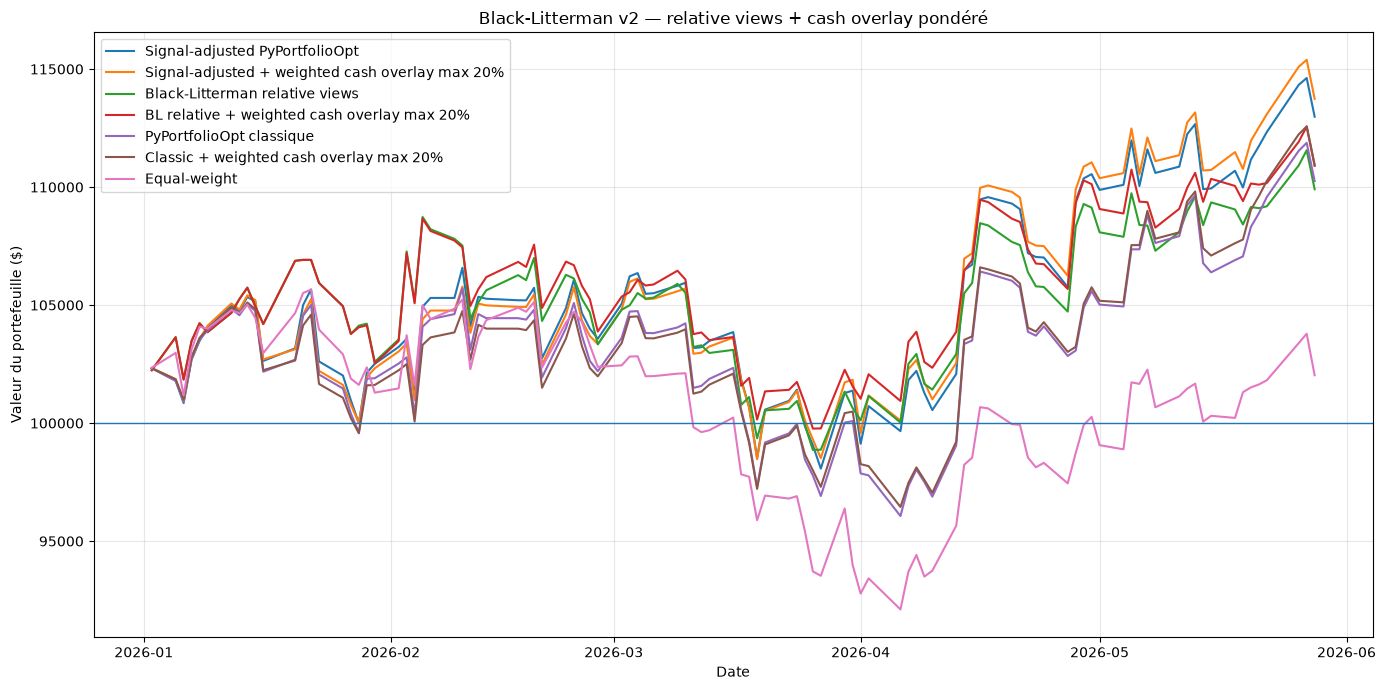

Graphique sauvegardé : /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_chart.png


In [12]:
returns_out = pd.DataFrame(index=asset_returns_by_day.index)
for name, series in comparison_series.items():
    returns_out[name] = series.reindex(returns_out.index).fillna(0.0)

values = INITIAL_CAPITAL * (1.0 + returns_out).cumprod()

plt.figure(figsize=(14, 7))
for col in values.columns:
    plt.plot(values.index, values[col], label=col)

plt.axhline(INITIAL_CAPITAL, linewidth=1)
plt.title("Black-Litterman v2 — relative views + cash overlay pondéré")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = RESULTS / "black_litterman_v2_chart.png"
plt.savefig(chart_path, dpi=160)
plt.show()

print("Graphique sauvegardé :", chart_path)

## 7. Exports

In [13]:
comparison_path = RESULTS / "black_litterman_v2_comparison.csv"
returns_path = RESULTS / "black_litterman_v2_returns.csv"
weights_path = RESULTS / "black_litterman_v2_weights.csv"
posterior_path = RESULTS / "black_litterman_v2_posterior_returns.csv"
views_path = RESULTS / "black_litterman_v2_relative_views.csv"
cash_exposures_path = RESULTS / "black_litterman_v2_cash_exposures.csv"
weighted_signals_path = RESULTS / "black_litterman_v2_weighted_signals.csv"
summary_path = RESULTS / "black_litterman_v2_summary.json"

comparison.to_csv(comparison_path, index=False)
returns_out.reset_index(names="date").to_csv(returns_path, index=False)
bl_weights_df.to_csv(weights_path, index=False)

if not bl_posterior_df.empty:
    bl_posterior_df.to_csv(posterior_path, index=False)

if not bl_views_df.empty:
    bl_views_df.to_csv(views_path, index=False)

cash_exposures = pd.DataFrame({
    "date": asset_returns_by_day.index,
    "signal_adjusted_equity_exposure": signal_exposure20.reindex(asset_returns_by_day.index).values,
    "bl_relative_equity_exposure": bl_exposure20.reindex(asset_returns_by_day.index).values,
    "classic_equity_exposure": classic_exposure20.reindex(asset_returns_by_day.index).values,
})
cash_exposures.to_csv(cash_exposures_path, index=False)

weighted_signals = pd.DataFrame({
    "date": asset_returns_by_day.index,
    "signal_adjusted_weighted_signal": signal_cash_score.reindex(asset_returns_by_day.index).values,
    "bl_relative_weighted_signal": bl_cash_score.reindex(asset_returns_by_day.index).values,
    "classic_weighted_signal": classic_cash_score.reindex(asset_returns_by_day.index).values,
})
weighted_signals.to_csv(weighted_signals_path, index=False)

summary = {
    "params": params,
    "best_strategy_by_sharpe": comparison.iloc[0].to_dict(),
    "comparison": comparison.to_dict(orient="records"),
}
summary_path.write_text(json.dumps(summary, indent=2, default=str))

print("Exports créés :")
for p in [
    comparison_path,
    returns_path,
    weights_path,
    posterior_path,
    views_path,
    cash_exposures_path,
    weighted_signals_path,
    summary_path,
    chart_path,
]:
    print("-", p)

Exports créés :
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_comparison.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_returns.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_weights.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_posterior_returns.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_relative_views.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_cash_exposures.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_weighted_signals.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_summary.json
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/black_litterman_v2_chart.png


## 8. Lecture attendue

Cette version doit répondre à deux questions :

1. **Les relative views améliorent-elles Black-Litterman ?**  
   Si oui, Black-Litterman est probablement mieux adapté en formulation relative qu’en formulation absolue.

2. **Le cash overlay pondéré améliore-t-il encore la stratégie ?**  
   Le cash overlay est plus rigoureux ici, car il dépend des actifs réellement détenus par chaque portefeuille.

Décision à prendre après exécution :

```text
Si BL relative + cash overlay bat Signal-adjusted + cash overlay :
    Black-Litterman devient candidat sérieux pour intégration dans engine_pypfopt.py.

Sinon :
    Black-Litterman reste une stratégie expérimentale.
    La stratégie finale reste Signal-adjusted + cash overlay max 20 %.
```